ΕΡΓΑΣΙΑ ΜΗΧΑΝΙΚΗΣ ΜΑΘΗΣΗΣ 2025 Α ΕΞΑΜΗΝΟ

ΔΙΔΑΣΚΩΝ: ΟΡΕΣΤΗΣ ΤΕΛΕΛΗΣ

ΦΟΙΤΗΤΗΣ: ΔΗΜΗΤΡΙΟΣ ΚΩΣΤΗΡΗΣ

ΑΜ: ΜΕ25021

ΕΡΩΤΗΜΑ Α

In [113]:
import pandas as pd
import numpy as np

Φόρτωση dataset και ενοποίηση του.

In [114]:
full_set = pd.concat(
    [
        pd.read_csv("TrainingSet.csv"),
        pd.read_csv("TestSet.csv")
    ],
    ignore_index=True
)

sold_set = pd.concat(
    [
        pd.read_csv("TrainingSubset.csv"),
        pd.read_csv("TestSubset.csv")
    ],
    ignore_index=True
)

print(full_set.shape, sold_set.shape)

(296048, 28) (89124, 33)


In [115]:
sold_set.head()

,EbayID,Price,PricePercent,StartingBidPercent,SellerName,SellerClosePercent,Category,PersonID,StartingBid,AvgPrice,...,BidCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,PriceBuckets,AuctionMedianPrice,IsInMedianRatio10Percent,IsInMedianRatio20Percent,IsInMedianRatio25Percent
0,350752140634,0.01,0.0038,0.0038,inkcasualty,0.725377,73396,33,0.01,2.5808,...,1,101,23,1726,1252,5,1.00,0,0,0
1,380610306320,5.55,1.0000,0.0018,prettysam1012,0.563847,27260,39,0.01,5.5500,...,7,1,1,603,340,10,5.55,1,1,1
2,151033305503,0.99,0.6832,0.6832,harryjean0,0.128269,73396,39,0.99,1.4490,...,1,26,1,2791,358,5,0.99,1,1,1
3,350756072255,0.06,1.0000,0.1666,inkcasualty,0.725377,73396,182,0.01,0.0600,...,2,13,1,1726,1252,5,0.06,1,1,1
4,121072982322,0.99,0.2826,0.2826,lock-em-up-bob,0.605851,73396,265,0.99,3.5025,...,1,71,3,1880,1139,5,0.99,1,1,1


Ορισμός target και features, αφαιρούνται features που θα οδηγούσαν σε data leakage και θα έκαναν το μοντέλο μεροληπτικό.

In [ ]:
from sklearn.model_selection import train_test_split

#ορισμός target και features

y = sold_set["Price"]
X = sold_set.drop(columns = ["Price", "EbayID", "PricePercent", "SellerName", "PersonID"])

#train - test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42)

In [117]:
print(y.value_counts())

Price
0.99      8393
9.99      2805
4.99      1471
2.99      1193
14.99     1132
          ... 
84.75        1
122.83       1
34.23        1
15.64        1
137.59       1
Name: count, Length: 7127, dtype: int64


In [118]:
y.head()

0    0.01
1    5.55
2    0.99
3    0.06
4    0.99
Name: Price, dtype: float64

In [119]:
X.head()

,StartingBidPercent,SellerClosePercent,Category,StartingBid,AvgPrice,EndDay,QuantitySold,HitCount,AuctionAvgHitCount,Authenticated,...,BidCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,PriceBuckets,AuctionMedianPrice,IsInMedianRatio10Percent,IsInMedianRatio20Percent,IsInMedianRatio25Percent
0,0.0038,0.725377,73396,0.01,2.5808,Friday,1,6,58,0,...,1,101,23,1726,1252,5,1.00,0,0,0
1,0.0018,0.563847,27260,0.01,5.5500,Sunday,1,16,9,0,...,7,1,1,603,340,10,5.55,1,1,1
2,0.6832,0.128269,73396,0.99,1.4490,Sunday,1,8,97,0,...,1,26,1,2791,358,5,0.99,1,1,1
3,0.1666,0.725377,73396,0.01,0.0600,Friday,1,4,15,0,...,2,13,1,1726,1252,5,0.06,1,1,1
4,0.2826,0.605851,73396,0.99,3.5025,Monday,1,4,28,0,...,1,71,3,1880,1139,5,0.99,1,1,1


Ιστόγραμμα κατανομής των τιμών πώλησης.

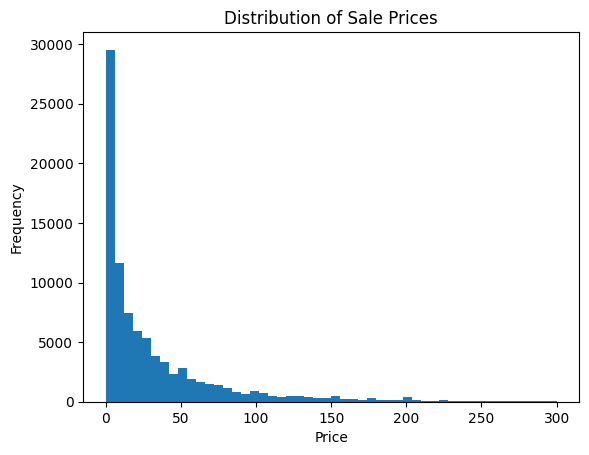

In [120]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Sale Prices")
plt.show()


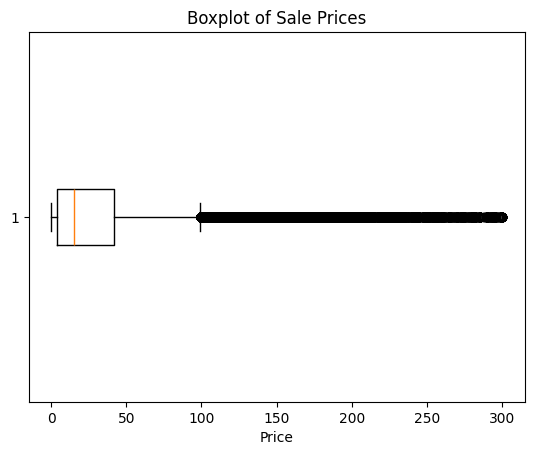

In [121]:
plt.boxplot(y, vert=False)
plt.xlabel("Price")
plt.title("Boxplot of Sale Prices")
plt.show()


In [122]:
print(y_train.value_counts(normalize=True))

Price
0.99      0.093803
9.99      0.031546
4.99      0.016478
2.99      0.013224
14.99     0.012855
            ...   
124.95    0.000016
36.26     0.000016
103.26    0.000016
26.84     0.000016
58.66     0.000016
Name: proportion, Length: 6074, dtype: float64


Προεπεξεργασία δεδομένων: διαχωρισμός numeric - categorical τιμών.

In [123]:
# Numeric features
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

# Categorical features
categorical_features = X_train.select_dtypes(include=["object"]).columns

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 27
Categorical features: 1


In [124]:
print(X_train.shape, X_test.shape)
X_train.head()


(62386, 28) (26738, 28)


,StartingBidPercent,SellerClosePercent,Category,StartingBid,AvgPrice,EndDay,QuantitySold,HitCount,AuctionAvgHitCount,Authenticated,...,BidCount,AuctionCount,AuctionSaleCount,SellerAuctionCount,SellerAuctionSaleCount,PriceBuckets,AuctionMedianPrice,IsInMedianRatio10Percent,IsInMedianRatio20Percent,IsInMedianRatio25Percent
34696,2.6208,0.500000,73409,12.99,4.9564,Friday,1,12,19,0,...,1,80,19,38,19,15,1.040,0,0,0
67361,0.6953,0.371753,73396,24.99,35.9374,Saturday,1,8,92,0,...,1,549,233,1232,458,25,16.320,0,0,0
66870,0.0085,0.497653,2832,0.99,116.0250,Monday,1,6,36,0,...,3,1,1,639,318,5,2.060,1,1,1
86116,0.3006,0.977273,27260,9.99,33.2325,Thursday,1,35,68,1,...,8,123,20,44,43,40,24.970,0,0,0
12496,0.3165,0.666667,27278,8.00,25.2695,Saturday,1,8,76,0,...,5,297,56,9,6,30,18.785,0,0,0


Εφαρμογή Standard Scaler και One Hot Encoder

In [125]:
# Data Preproccesing

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown= "ignore"), categorical_features)

    ]
)

Αλγόριθμος 1: Linear Regression

Δημιουργία Pipeline πρώτου μοντέλου.

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(
    steps = [
        ("preprocces", preprocessor),
        ("model", LinearRegression())
    ]
)


Εκπαίδευση, πρόβλεψη και δημιουργία metrics της Linear Regression.

In [ ]:
model.fit(X_train, y_train)
y_pred_lr = model.predict(X_test) 


from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#metrics

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [128]:
y_test.describe()


count    26738.000000
mean        32.460115
std         45.355686
min          0.010000
25%          3.520000
50%         14.990000
75%         41.000000
max        299.990000
Name: Price, dtype: float64

Αλγόρθιμος 2: Gradient Descent

Δημιουργία Pipeline δεύτερου μοντέλου.

In [129]:
from sklearn.linear_model import SGDRegressor

GD = Pipeline(
    steps= [
        ("preprocess", preprocessor),
        ("model", SGDRegressor(
            loss= "squared_error",
            learning_rate= "constant",
            eta0= 0.00001,
            max_iter= 1000,
            random_state=42
        ))

    ]
)

Εκπαίδευση, πρόβλεψη και δημιουργία metrics της Linear Regression.

In [130]:
GD.fit(X_train, y_train) #εκπαίδευση
ypredGD = GD.predict(X_test) #πρόβλεψη

#metrics

rmse_gd = np.sqrt(mean_squared_error(y_test, ypredGD))
r2_gd = r2_score(y_test, ypredGD)
mae_gd = mean_absolute_error(y_test, ypredGD)

/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dimkostir/Desktop/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΕΤΑΠΤΥΧΙΑΚΟ/ΜΗΧΑΝΙΚΗ ΜΑΘΗΣΗ/Τελέλης ΕΡΓΑΣΙΑ/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [133]:
print("LR  RMSE:", rmse_lr)
print("LR  R2  :", r2_lr)
print("LR  MAE :", mae_lr)

LR  RMSE: 1.4906287651213121
LR  R2  : 0.9989198308820851
LR  MAE : 1.2902980457618003


In [132]:
print("GD  RMSE:", rmse_gd)
print("GD  R2  :", r2_gd)
print("GD  MAE :", mae_gd)

GD  RMSE: 1.4951212809488683
GD  R2  : 0.9989133101579895
GD  MAE : 1.2934004013044138
